# 73 - Code Challenge: How Wide Should the Classifier Be?

**Section:** CNNs | **Prereqs:** `CNNs/CodeChallenge_VaryingNumber_of_Channels.ipynb` | **Next:** `CNNs/Gaussian_Blur.ipynb`

The complement to the previous notebook: hold the convolutional stack fixed and
sweep the width of the fully connected head from 5 to 500 units.

**The expected result, and it is the useful one:** the curve is flat almost
immediately. Once the conv stack has produced good features, the classifier's job
is easy - a handful of units is enough to separate two classes.

**The lesson.** Capacity in a CNN belongs in the *convolutional* layers, which
learn the representation. The fully connected head only draws a decision boundary
in the space those features define, and needs very little capacity to do it. Yet
in a naive architecture the head is where most of the parameters are - which is
exactly why modern designs use global average pooling and a single small `Linear`
layer.

**The historical arc in one line:** AlexNet's classifier head was around 58M
parameters; ResNet's is about 2M and it is more accurate. That change is this
notebook's finding, applied.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

import torchsummary

In [4]:
# The synthetic dataset for this notebook: 2-D Gaussian blobs at random centres,
# with one of two widths (sigma = 1.8 or 2.4), plus noise.
# The label is which sigma was used - i.e. the task is 'is this blob wide or
# narrow', which is position-independent by construction. Perfect for a CNN, and
# nearly impossible for an FNN, which would have to learn it separately at every
# location.
img_size = 91
n_perClass = 10000

sigma = [1.8,2.4]


x = np.linspace(-4,4,img_size)

X,Y = np.meshgrid(x,x)


images = np.zeros((2*n_perClass , 1, img_size,img_size), dtype=float)
labels = np.zeros(2*n_perClass)

for i in range(2*n_perClass):

  center = 2*np.random.randn(2)

  X_hat = X - center[0]
  Y_hat = Y - center[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma[i%2]))

  noise = np.random.randn(*G.shape) / 5

  images[i,:,:,:] = G - noise
  labels[i] = i%2


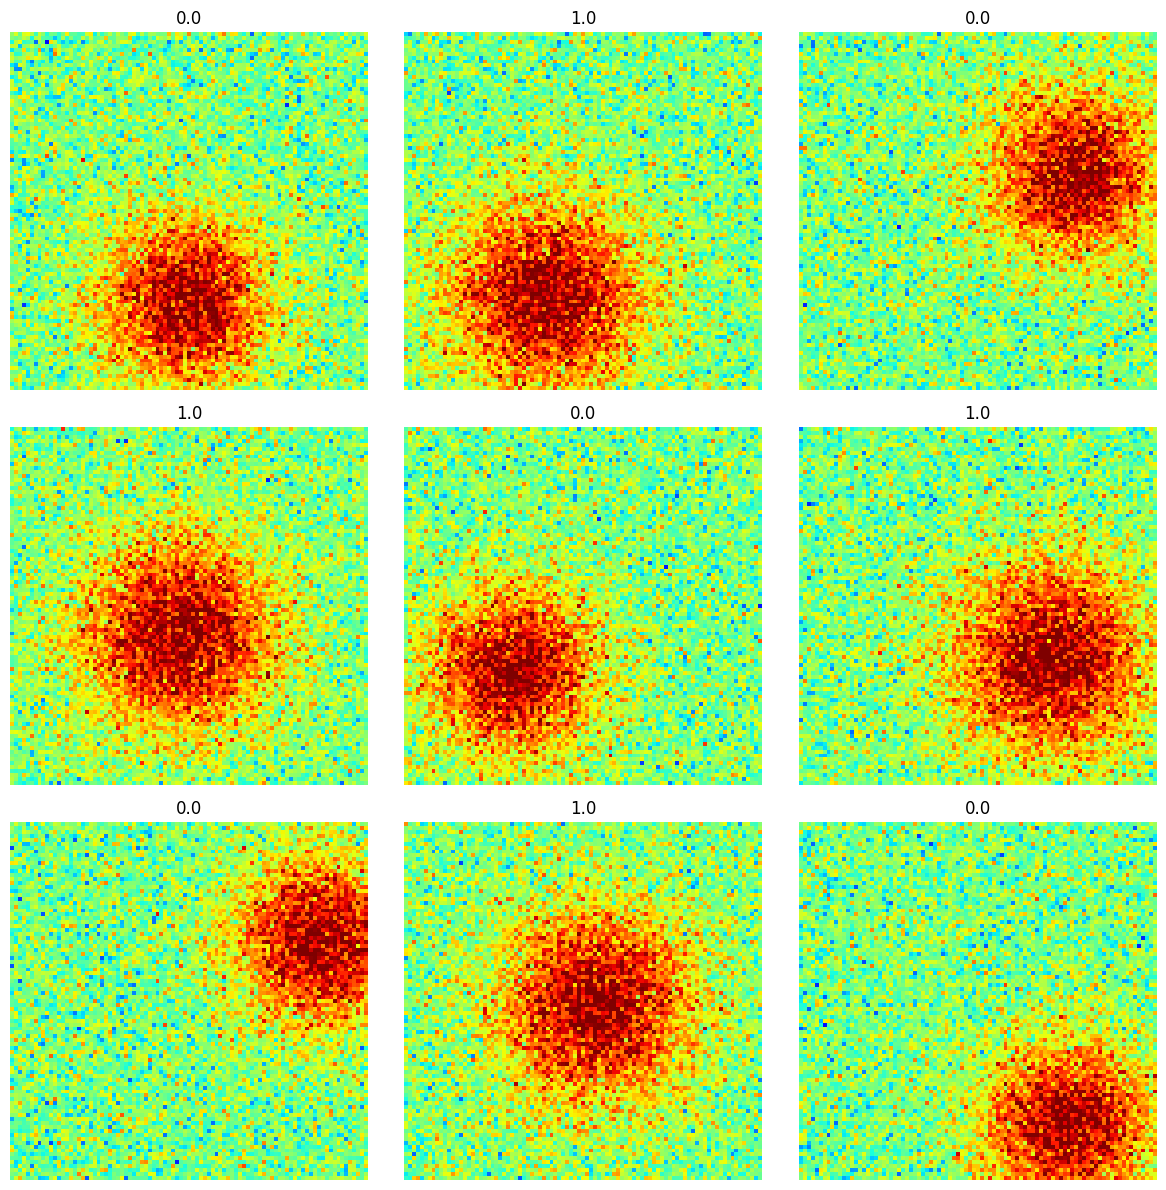

In [5]:
# Sample images.
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(2*n_perClass, len(ax))):
  ax[i].imshow(np.squeeze(images[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].set_title(str(labels[i].item()));
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Split and loaders.
# Data Loader

device = ('cuda' if torch.cuda.is_available() else 'cpu')
train_data, test_data, train_label, test_label = train_test_split(images, labels, test_size=0.10)

train_tensor = torch.tensor(train_data, dtype=torch.float , device=device)
train_label = torch.tensor(train_label, dtype=torch.long, device=device)

test_tensor = torch.tensor(test_data, dtype=torch.float , device=device)
test_label = torch.tensor(test_label, dtype=torch.long, device=device)

train_dataset = TensorDataset(train_tensor, train_label)
test_dataset = TensorDataset(test_tensor , test_label)

bs = 8
train_loader = DataLoader(train_dataset ,batch_size=bs , drop_last=True, shuffle=True)
test_loder = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [7]:
# The conv stack is FIXED (32 -> 64 -> 128); only the FC head is parameterised:
# Linear(128, n) -> Linear(n, n/2) -> Linear(n/2, 1).
# Isolating one variable is the whole design of the experiment.
class BlurModel(nn.Module):
  def __init__(self,n):
    super().__init__()

    self.conv = nn.Sequential(
        nn.Conv2d(1,32,stride=2,padding=1,kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d((2,2)),

        nn.Conv2d(32,64, stride=1, padding=1, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d((2,2)),

        nn.Conv2d(64,128,stride=1, padding=1, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d((2,2)),

        nn.AdaptiveAvgPool2d((1,1))
    )

    self.fc1 = nn.Linear(128,n)
    self.fc2 = nn.Linear(n, int(n/2))
    self.out = nn.Linear(int(n/2),1)


  def forward(self,x):

    x = self.conv(x)

    x = x.view(x.size(0), -1)

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return self.out(x)


In [8]:
# A small instance (n=25).
test_model = BlurModel(25)
test_model.to(device)

BlurModel(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (fc1): Linear(in_features=128, out_features=25, bias=True)
  (fc2): Linear(in_features=25, out_features=12, bias=True)
  (out): Linear(in_features=12, out_features=1, bias=True)
)

In [9]:
# The summary - note how few parameters the head has when n is small, compared
# with the conv stack.
torchsummary.summary(test_model, input_size=(1,91,91))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 46, 46]             320
              ReLU-2           [-1, 32, 46, 46]               0
         MaxPool2d-3           [-1, 32, 23, 23]               0
            Conv2d-4           [-1, 64, 23, 23]          18,496
              ReLU-5           [-1, 64, 23, 23]               0
         MaxPool2d-6           [-1, 64, 11, 11]               0
            Conv2d-7          [-1, 128, 11, 11]          73,856
              ReLU-8          [-1, 128, 11, 11]               0
         MaxPool2d-9            [-1, 128, 5, 5]               0
AdaptiveAvgPool2d-10            [-1, 128, 1, 1]               0
           Linear-11                   [-1, 25]           3,225
           Linear-12                   [-1, 12]             312
           Linear-13                    [-1, 1]              13
Total params: 96,222
Trainable params: 

In [10]:
# 15 widths from 5 to 500.
n_params = np.linspace(5,500,15, dtype=int)
n_params

array([  5,  40,  75, 111, 146, 181, 217, 252, 287, 323, 358, 393, 429,
       464, 500])

In [11]:
# Training function taking the head width. 10 epochs per run.
def train_model(n: int):

  model = BlurModel(n).to(device)

  lr = 1e-3
  epochs = 10

  lossFunc = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(model.parameters(),lr=lr)

  losses = []
  train_acc = []
  val_acc = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat, y.unsqueeze(1).float())
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( ((yhat > 0) == y.float().unsqueeze(1)).float().detach().cpu()).item())

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))


    # Now Validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loder))
      val_acc.append(100 * torch.mean( ((model(X) > 0) == Y.float().unsqueeze(1)).float().detach().cpu()).item())

    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Number of parameters : {n} | Epoch : {epoch} | loss : {losses[epoch]:.2f} | train_acc : {train_acc[epoch]:.2f}  | Val Acc : {val_acc[epoch]:.2f}')

  return losses[-1], train_acc[-1], val_acc[-1]

In [12]:
# The sweep: 15 models.
final_losses = []
final_train_acc = []
final_val_acc = []

for n in n_params:
  loss , train_acc, val_acc = train_model(n)

  final_losses.append(loss)
  final_train_acc.append(train_acc)
  final_val_acc.append(val_acc)

  print()

Number of parameters : 5 | Epoch : 0 | loss : 0.69 | train_acc : 49.66  | Val Acc : 51.40
Number of parameters : 5 | Epoch : 9 | loss : 0.69 | train_acc : 49.48  | Val Acc : 48.60

Number of parameters : 40 | Epoch : 0 | loss : 0.57 | train_acc : 66.67  | Val Acc : 82.55
Number of parameters : 40 | Epoch : 9 | loss : 0.05 | train_acc : 98.07  | Val Acc : 98.35

Number of parameters : 75 | Epoch : 0 | loss : 0.37 | train_acc : 80.56  | Val Acc : 92.30
Number of parameters : 75 | Epoch : 9 | loss : 0.04 | train_acc : 98.43  | Val Acc : 98.15

Number of parameters : 111 | Epoch : 0 | loss : 0.54 | train_acc : 68.30  | Val Acc : 84.10
Number of parameters : 111 | Epoch : 9 | loss : 0.05 | train_acc : 98.02  | Val Acc : 97.60

Number of parameters : 146 | Epoch : 0 | loss : 0.40 | train_acc : 77.31  | Val Acc : 95.35
Number of parameters : 146 | Epoch : 9 | loss : 0.04 | train_acc : 98.48  | Val Acc : 98.85

Number of parameters : 181 | Epoch : 0 | loss : 0.41 | train_acc : 76.61  | Val Acc

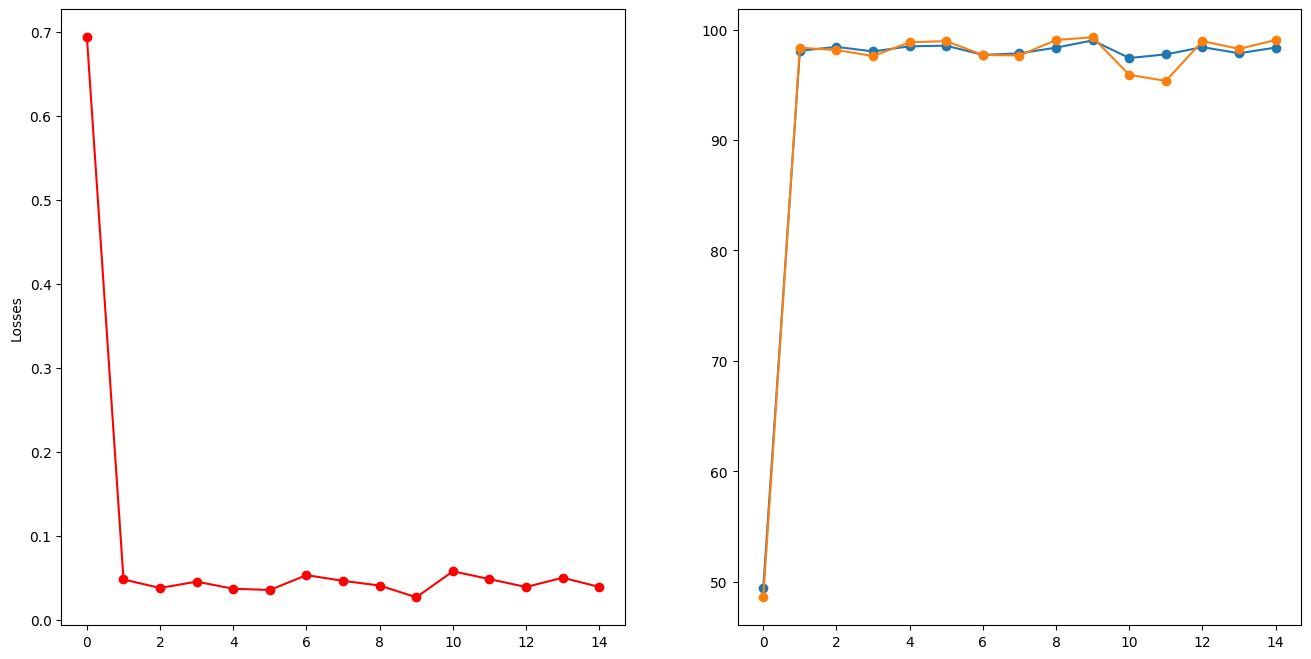

In [13]:
# Loss and accuracy vs head width.
# Expect a flat line: 5 units are nearly as good as 500. The convolutional stack
# did the work; the classifier only draws a boundary in the feature space it
# produced.
# (The x-axis is the list index rather than n_params, so read positions as the
# 15 sweep points in order.)
from matplotlib import legend
fig ,ax = plt.subplots(1,2, figsize=(16,8))

ax[0].plot(final_losses, 'ro-')
ax[0].set_ylabel("Losses")


ax[1].plot(final_train_acc, 'o-')
ax[1].plot(final_val_acc, 'o-');